##Random_Forest

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error ,r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Maharashtr_Industrial_electricity_demand.xlsx to Maharashtr_Industrial_electricity_demand.xlsx


In [ ]:
df = pd.read_excel("Maharashtr_Industrial_electricity_demand.xlsx")

df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

print(df.head())

                  State      Sector  Industrial_Consumption_MU
Date                                                          
2021-01-01  Maharashtra  Industries                1101.122677
2021-01-02  Maharashtra  Industries                1070.902100
2021-01-03  Maharashtra  Industries                1098.228003
2021-01-04  Maharashtra  Industries                1145.449140
2021-01-05  Maharashtra  Industries                1126.855124


In [ ]:
monthly_data = df.resample('M').sum()
print(monthly_data.head())

                                                        State  \
Date                                                            
2021-01-31  MaharashtraMaharashtraMaharashtraMaharashtraMa...   
2021-02-28  MaharashtraMaharashtraMaharashtraMaharashtraMa...   
2021-03-31  MaharashtraMaharashtraMaharashtraMaharashtraMa...   
2021-04-30  MaharashtraMaharashtraMaharashtraMaharashtraMa...   
2021-05-31  MaharashtraMaharashtraMaharashtraMaharashtraMa...   

                                                       Sector  \
Date                                                            
2021-01-31  IndustriesIndustriesIndustriesIndustriesIndust...   
2021-02-28  IndustriesIndustriesIndustriesIndustriesIndust...   
2021-03-31  IndustriesIndustriesIndustriesIndustriesIndust...   
2021-04-30  IndustriesIndustriesIndustriesIndustriesIndust...   
2021-05-31  IndustriesIndustriesIndustriesIndustriesIndust...   

            Industrial_Consumption_MU  
Date                                   
2021-01-

/tmp/ipykernel_3230/1715961721.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M').sum()


In [ ]:
# Lag features
for lag in [1, 2, 3, 6, 12]:
    df[f'lag_{lag}'] = df['Industrial_Consumption_MU'].shift(lag)

    # Rolling
    df['rolling_mean_3'] = df['Industrial_Consumption_MU'].rolling(3).mean()
    df['rolling_mean_6'] = df['Industrial_Consumption_MU'].rolling(6).mean()

    # Date features
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter

    # Drop NA
    df = df.dropna()

In [ ]:
# Apply feature engineering to monthly_data
monthly_data_fe = monthly_data.copy()

# Lag features
for lag in [1, 2, 3, 6, 12]:
    monthly_data_fe[f'lag_{lag}'] = monthly_data_fe['Industrial_Consumption_MU'].shift(lag)

# Rolling features
monthly_data_fe['rolling_mean_3'] = monthly_data_fe['Industrial_Consumption_MU'].rolling(3).mean()
monthly_data_fe['rolling_mean_6'] = monthly_data_fe['Industrial_Consumption_MU'].rolling(6).mean()

# Date features
monthly_data_fe['month'] = monthly_data_fe.index.month
monthly_data_fe['quarter'] = monthly_data_fe.index.quarter

# Drop NA values created by feature engineering
monthly_data_fe = monthly_data_fe.dropna()

# Split data into training and testing sets from the feature-engineered monthly data
train = monthly_data_fe[monthly_data_fe.index < '2025-01-01']
test  = monthly_data_fe[monthly_data_fe.index >= '2025-01-01']

# Define the features to be used for training
features = ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'month', 'quarter']

X_train = train[features]
y_train = train['Industrial_Consumption_MU']

X_test = test[features]
y_test = test['Industrial_Consumption_MU']

In [ ]:
Rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
Rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Define and fit the model (moved from cell Nmf1_Rm3gA17)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

Rf_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, Rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, Rf_pred)))
print("R²:", r2_score(y_test, Rf_pred))

MAE: 642.7944577352573
RMSE: 948.5695807345867
R²: 0.7351520780206179


In [ ]:
last_data = monthly_data_fe.iloc[-1]

# Ensure next_input includes all 9 features the model was trained on
# The 'features' list is defined in a previous cell (4bTEBL_u602r)
# Create a DataFrame for prediction to maintain feature names and avoid the UserWarning
next_input = pd.DataFrame([last_data[features].values], columns=features)

next_prediction = model.predict(next_input)

print("Predicted Next Month Demand (MU):", next_prediction[0])

Predicted Next Month Demand (MU): 42450.23059154133


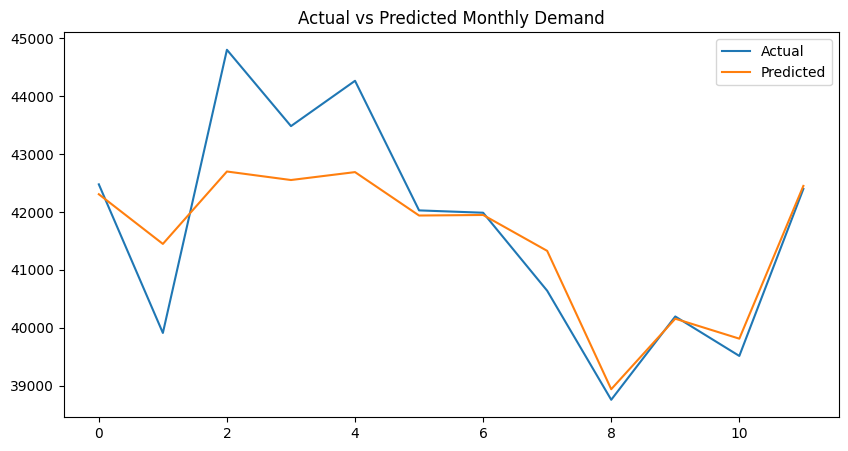

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(Rf_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Monthly Demand")
plt.show()

##XGboost

In [ ]:
pip install xgboost

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor


In [ ]:
xgb = XGBRegressor(objective='reg:squarederror')

In [ ]:
param_dist = {
    'learning_rate': [0.05],
    'max_depth': [6],
    'subsample': [0.8],
    'n_estimators': [100, 200, 300]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    verbose=1,
    random_state=42
)

In [ ]:
random_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 3 candidates, totalling 9 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=5,
                   param_distributions={'learning_rate': [0.05],
                                        'max_depth': [6],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8]},
                   random_state=42, verbose=1)

In [ ]:
best_xgb = random_search.best_estimator_

In [ ]:
xgb_pred = best_xgb.predict(X_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R²:", r2_score(y_test, xgb_pred))

MAE: 831.5609669881123
RMSE: 984.2681161955618
R²: 0.7148423564416168


In [ ]:
last_data_xgb = monthly_data_fe.iloc[-1]
# Create a DataFrame for prediction, ensuring all features are present and named correctly
next_input_xgb = pd.DataFrame([last_data_xgb[features].values], columns=features)
next_pred = best_xgb.predict(next_input_xgb)

In [ ]:
print("Next Month Prediction (XGBoost):", next_pred[0])

Next Month Prediction (XGBoost): [39684.688]


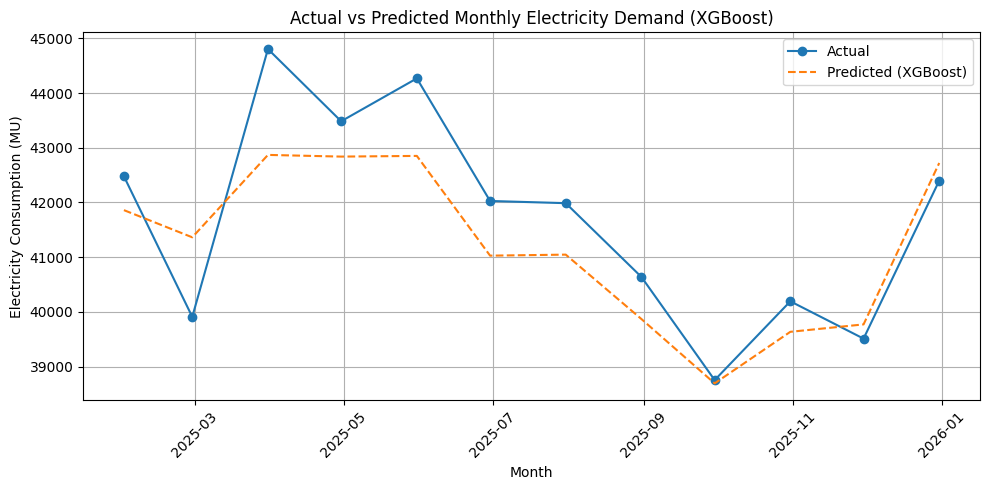

In [ ]:
import matplotlib.pyplot as plt

# Convert index to list (for better plotting)
dates = test.index

plt.figure(figsize=(10,5))

# Actual values (using the original 'test' DataFrame for dates and values)
plt.plot(dates, test['Industrial_Consumption_MU'], label="Actual", marker='o')

# Predicted values
plt.plot(dates, xgb_pred, label="Predicted (XGBoost)", linestyle='--')

plt.title("Actual vs Predicted Monthly Electricity Demand (XGBoost)")
plt.xlabel("Month")
plt.ylabel("Electricity Consumption (MU)")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##LSTM

In [ ]:
pip install tensorflow

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Load data
df = pd.read_excel("Maharashtr_Industrial_electricity_demand.xlsx")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Monthly aggregation
monthly = df.resample('ME').sum() # Changed 'M' to 'ME'

# Select target
data = monthly[['Industrial_Consumption_MU']]

# Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_dataset(data, time_step=3):
    X, y = [], []
    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 3
X, y = create_dataset(scaled_data, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Model
model = Sequential()
model.add(Input(shape=(time_step, 1))) # Added Input layer as recommended
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compile
model.compile(optimizer='adam', loss='mean_squared_error')

# Train
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

# Prediction
lstm_pred = model.predict(X_test)

# Inverse scaling
lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("MAE:", mean_absolute_error(y_test_actual, lstm_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, lstm_pred)))
print("R²:", r2_score(y_test, lstm_pred))

# Next month prediction
last_sequence = scaled_data[-time_step:]
last_sequence = last_sequence.reshape(1, time_step, 1)

next_pred = model.predict(last_sequence)
next_pred = scaler.inverse_transform(next_pred)

print("Next Month Prediction (LSTM):", next_pred[0][0])

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.3084
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2699
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2484
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2193
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1924
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1714
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1515
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1280
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1142
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0918
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0775
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0656
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0547
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0449
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0384
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━

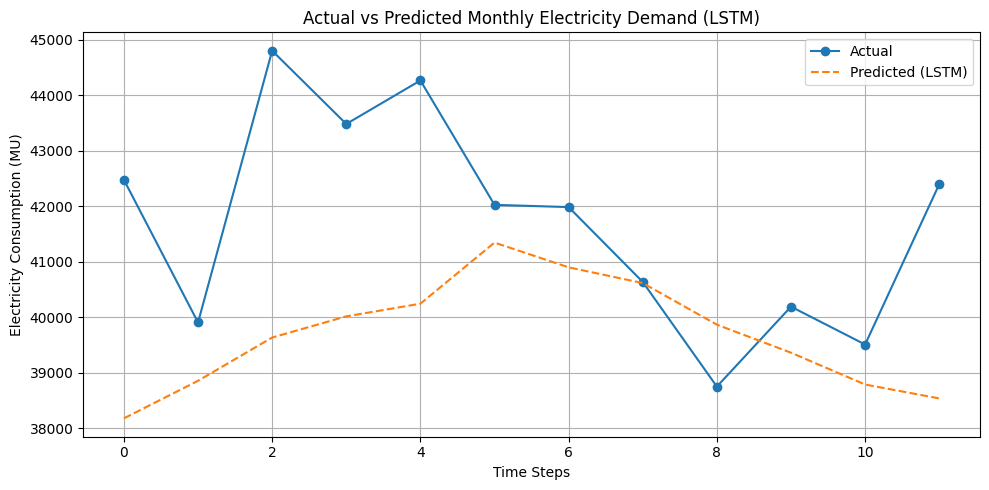

In [ ]:
x_axis = range(len(y_test_actual))

plt.figure(figsize=(10,5))

# Actual
plt.plot(x_axis, y_test_actual, label="Actual", marker='o')

# Predicted
plt.plot(x_axis, lstm_pred, label="Predicted (LSTM)", linestyle='--')

plt.title("Actual vs Predicted Monthly Electricity Demand (LSTM)")
plt.xlabel("Time Steps")
plt.ylabel("Electricity Consumption (MU)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

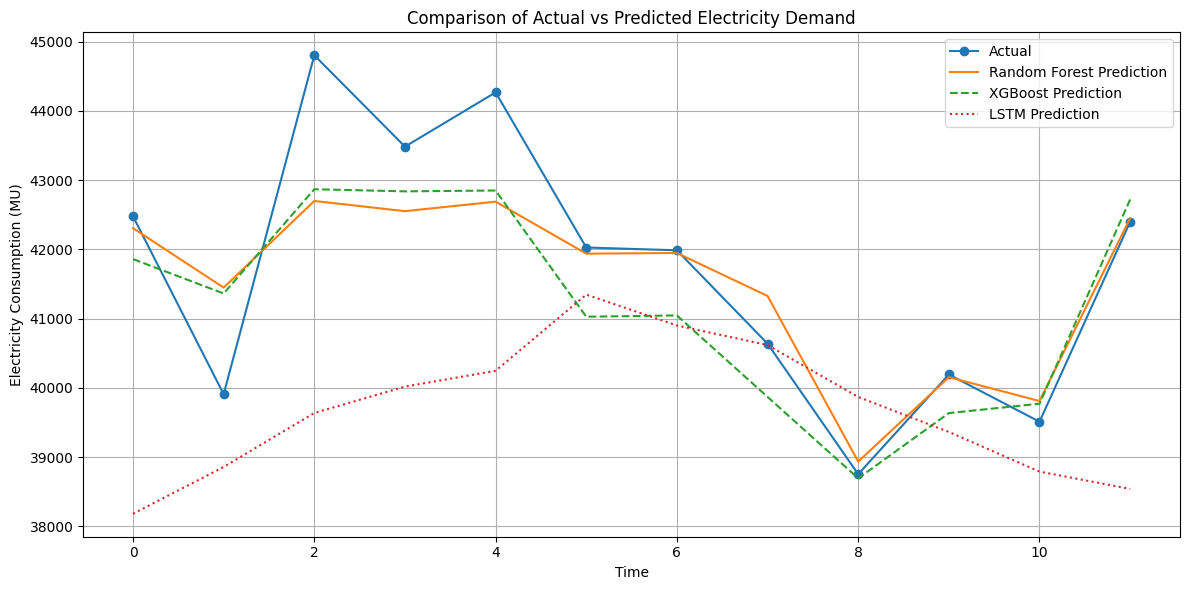

In [ ]:
plt.figure(figsize=(12,6))

# Actual
plt.plot(y_test_actual, label="Actual", marker='o')

# RF
plt.plot(Rf_pred, label="Random Forest Prediction", linestyle='-')

# XGBoost
plt.plot(xgb_pred, label="XGBoost Prediction", linestyle='--')

# LSTM
plt.plot(lstm_pred, label="LSTM Prediction", linestyle=':')

plt.title("Comparison of Actual vs Predicted Electricity Demand")
plt.xlabel("Time")
plt.ylabel("Electricity Consumption (MU)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

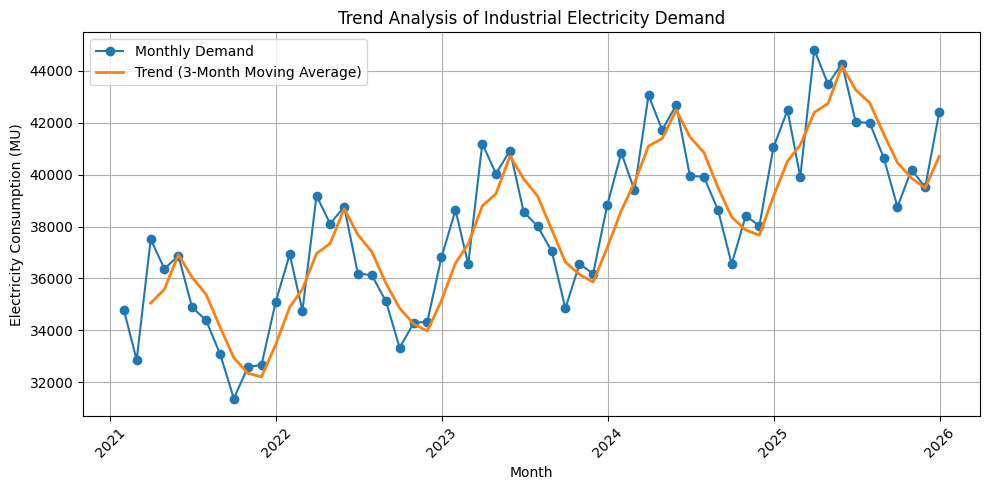

In [ ]:
import matplotlib.pyplot as plt

# Trend Plot
plt.figure(figsize=(10,5))

plt.plot(monthly_data.index,
         monthly_data['Industrial_Consumption_MU'],
         label='Monthly Demand',
         marker='o')

# Rolling mean (trend line)
trend = monthly_data['Industrial_Consumption_MU'].rolling(window=3).mean()

plt.plot(monthly_data.index, trend,
         label='Trend (3-Month Moving Average)',
         linewidth=2)

plt.title("Trend Analysis of Industrial Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Electricity Consumption (MU)")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

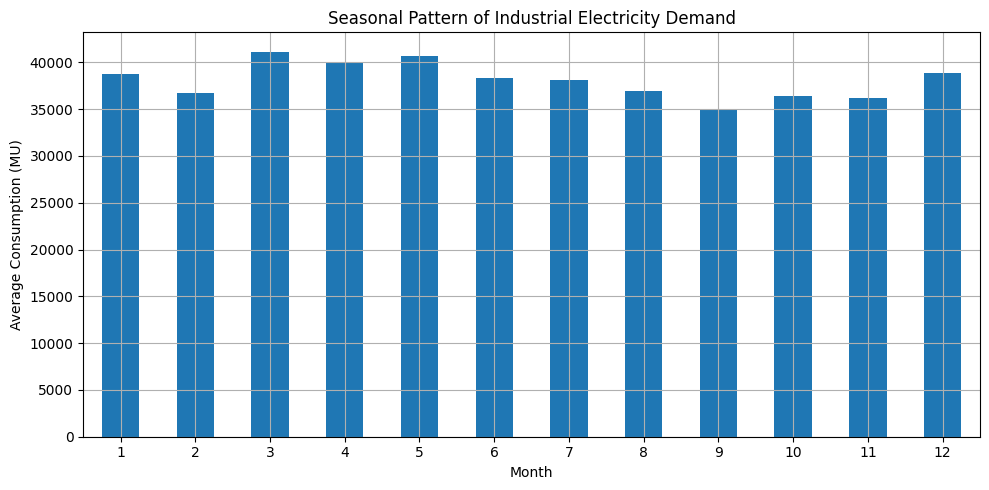

In [ ]:
# Extract month
monthly_data['Month'] = monthly_data.index.month

# Group by month
seasonality = monthly_data.groupby('Month')['Industrial_Consumption_MU'].mean()

# Plot
plt.figure(figsize=(10,5))

seasonality.plot(kind='bar')

plt.title("Seasonal Pattern of Industrial Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Average Consumption (MU)")
plt.grid(True)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

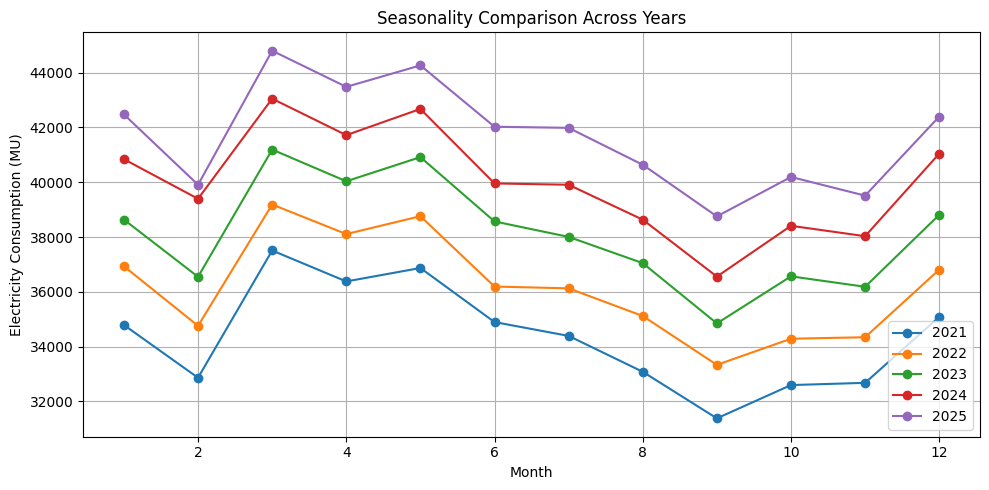

In [ ]:
plt.figure(figsize=(10,5))

for year in monthly_data.index.year.unique():
    yearly = monthly_data[monthly_data.index.year == year]
    plt.plot(yearly.index.month,
             yearly['Industrial_Consumption_MU'],
             marker='o',
             label=str(year))

plt.title("Seasonality Comparison Across Years")
plt.xlabel("Month")
plt.ylabel("Electricity Consumption (MU)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()